#STOCK MARKET DATASET

In [34]:
import pandas as pd
import numpy as np
#loading dataset
df = pd.read_excel('/content/yahoo_data[1].xlsx')
print(df.head())


           Date      Open      High       Low    Close*  Adj Close**  \
0  Apr 28, 2023  33797.43  34104.56  33728.40  34098.16     34098.16   
1  Apr 27, 2023  33381.66  33859.75  33374.65  33826.16     33826.16   
2  Apr 26, 2023  33596.34  33645.83  33235.85  33301.87     33301.87   
3  Apr 25, 2023  33828.34  33875.49  33525.39  33530.83     33530.83   
4  Apr 24, 2023  33805.04  33891.15  33726.09  33875.40     33875.40   

      Volume  
0  354310000  
1  343240000  
2  321170000  
3  297880000  
4  252020000  


The date tells on what day the transaction occured. the open is the stock market opening price, high is the highest it went, low is the lowest it went and close is the value at which the market closed. and the Adj Close price is the closing price of a stock after accounting for any corporate actions that occurred before the next day's open.

#EDA

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1258 non-null   object 
 1   Open         1258 non-null   float64
 2   High         1258 non-null   float64
 3   Low          1258 non-null   float64
 4   Close*       1258 non-null   float64
 5   Adj Close**  1258 non-null   float64
 6   Volume       1258 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 68.9+ KB
None


In [30]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close*,0
Adj Close**,0
Volume,0


No missing values.

In [33]:
df.duplicated().sum()

np.int64(0)

no duplicates.

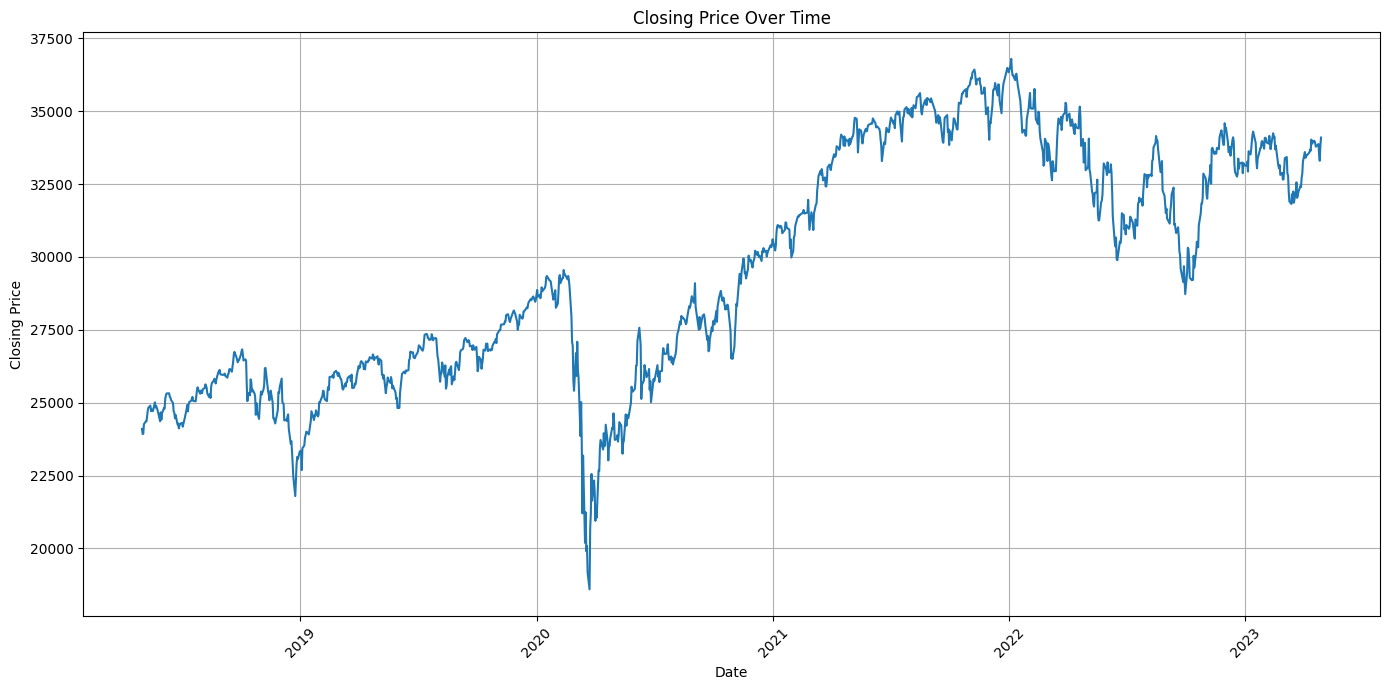

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Close*', data=df)
plt.title('Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

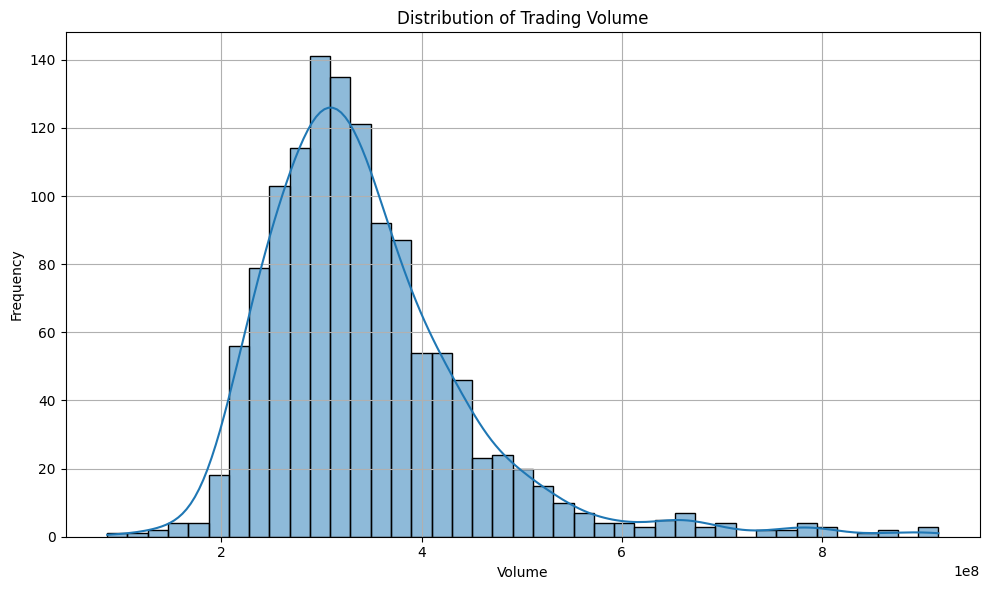

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting a histogram for 'Volume' to see its distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Volume'], kde=True)
plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

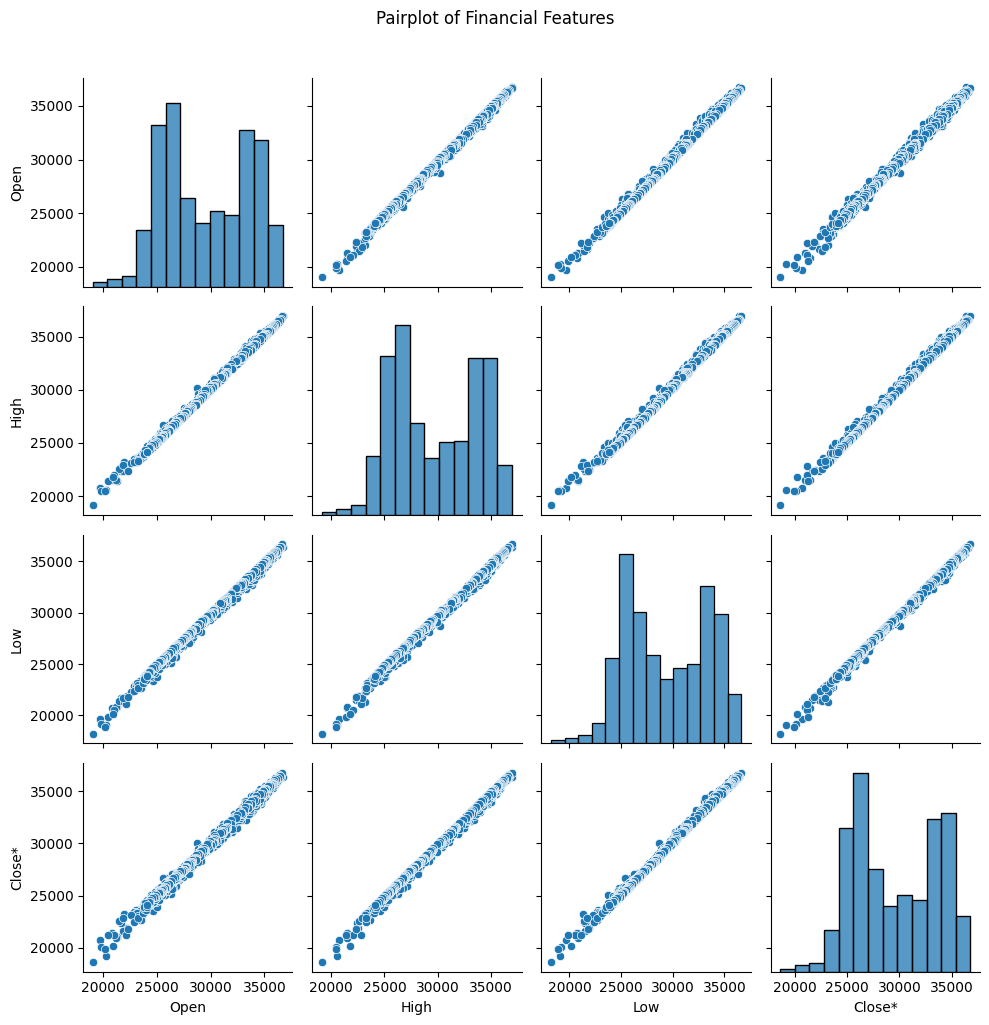

In [13]:
# Plotting a pairplot for the financial features
sns.pairplot(df[['Open', 'High', 'Low', 'Close*']])
plt.suptitle('Pairplot of Financial Features', y=1.02) # Adjust title position
plt.tight_layout()
plt.show()

## Linear Regression: Open Price vs. High Price

In [14]:
# Define X and y for 'Open' vs 'High'
X_new = df[['Open']]
y_new = df['High']

print("Shape of X_new:", X_new.shape)
print("Shape of y_new:", y_new.shape)
print("First 5 rows of X_new:\n", X_new.head())
print("First 5 rows of y_new:\n", y_new.head())

Shape of X_new: (1258, 1)
Shape of y_new: (1258,)
First 5 rows of X_new:
        Open
0  33797.43
1  33381.66
2  33596.34
3  33828.34
4  33805.04
First 5 rows of y_new:
 0    34104.56
1    33859.75
2    33645.83
3    33875.49
4    33891.15
Name: High, dtype: float64


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split the new data into training and testing sets (80% train, 20% test)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

print("Shape of X_train_new:", X_train_new.shape)
print("Shape of X_test_new:", X_test_new.shape)
print("Shape of y_train_new:", y_train_new.shape)
print("Shape of y_test_new:", y_test_new.shape)

# Create a new Linear Regression model instance
model_open_high = LinearRegression()

# Fit the model to the training data
model_open_high.fit(X_train_new, y_train_new)

# Print the intercept and coefficient(s)
print(f"Model Intercept (Open vs High): {model_open_high.intercept_:.2f}")
print(f"Model Coefficient (Open vs High): {model_open_high.coef_[0]:.2f}")

Shape of X_train_new: (1006, 1)
Shape of X_test_new: (252, 1)
Shape of y_train_new: (1006,)
Shape of y_test_new: (252,)
Model Intercept (Open vs High): 206.69
Model Coefficient (Open vs High): 1.00


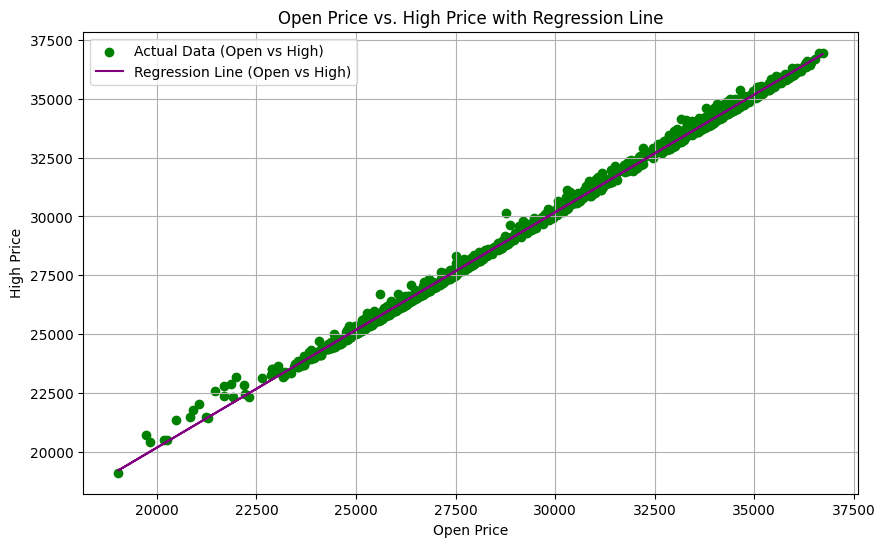

In [16]:
import matplotlib.pyplot as plt

# Predict y values using the trained model (on the full X_new for visualization)
y_pred_new = model_open_high.predict(X_new)

# Create the scatter plot of original data points
plt.figure(figsize=(10, 6))
plt.scatter(X_new, y_new, color='green', label='Actual Data (Open vs High)')

# Overlay the regression line
plt.plot(X_new, y_pred_new, color='purple', label='Regression Line (Open vs High)')

# Add labels, title, and legend
plt.xlabel('Open Price')
plt.ylabel('High Price')
plt.title('Open Price vs. High Price with Regression Line')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set for 'Open' vs 'High'
y_pred_test_new = model_open_high.predict(X_test_new)

# Calculate evaluation metrics
mae_new = mean_absolute_error(y_test_new, y_pred_test_new)
mse_new = mean_squared_error(y_test_new, y_pred_test_new)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(y_test_new, y_pred_test_new)

# Print the metrics
print(f"Mean Absolute Error (MAE) for Open vs High: {mae_new:.2f}")
print(f"Mean Squared Error (MSE) for Open vs High: {mse_new:.2f}")
print(f"Root Mean Squared Error (RMSE) for Open vs High: {rmse_new:.2f}")
print(f"R-squared (R2) for Open vs High: {r2_new:.4f}")

Mean Absolute Error (MAE) for Open vs High: 133.62
Mean Squared Error (MSE) for Open vs High: 39824.84
Root Mean Squared Error (RMSE) for Open vs High: 199.56
R-squared (R2) for Open vs High: 0.9976


#Open vs Close - Linear Regression

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Create a Linear Regression model instance
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Print the intercept and coefficient(s)
print(f"Model Intercept: {model.intercept_:.2f}")
print(f"Model Coefficient (Open): {model.coef_[0]:.2f}")

Shape of X_train: (1006, 1)
Shape of X_test: (252, 1)
Shape of y_train: (1006,)
Shape of y_test: (252,)
Model Intercept: 60.90
Model Coefficient (Open): 1.00


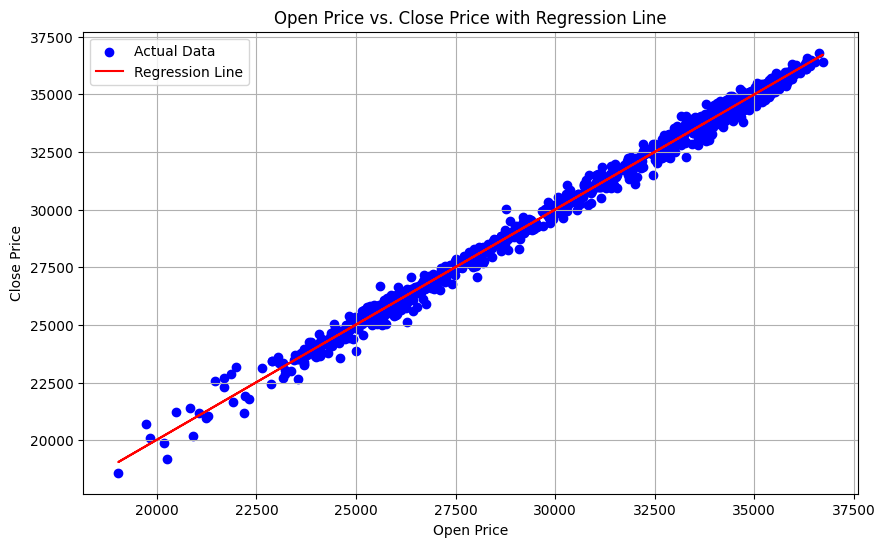

In [5]:
import matplotlib.pyplot as plt

# Predict y values using the trained model
y_pred = model.predict(X)

# Create the scatter plot of original data points
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')

# Overlay the regression line
plt.plot(X, y_pred, color='red', label='Regression Line')

# Add labels, title, and legend
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.title('Open Price vs. Close Price with Regression Line')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
X = df[['Open']]
y = df['Close*']
#Deciding on my input and output variables as open being the price where the stock market opens and when closes.
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 rows of X:\n", X.head())
print("First 5 rows of y:\n", y.head())

Shape of X: (1258, 1)
Shape of y: (1258,)
First 5 rows of X:
        Open
0  33797.43
1  33381.66
2  33596.34
3  33828.34
4  33805.04
First 5 rows of y:
 0    34098.16
1    33826.16
2    33301.87
3    33530.83
4    33875.40
Name: Close*, dtype: float64


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_test = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

# Print the metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 204.87
Mean Squared Error (MSE): 86846.33
Root Mean Squared Error (RMSE): 294.70
R-squared (R2): 0.9946


## Linear Regression: High Price vs. Low Price

In [20]:
# Define X and y for 'High' vs 'Low'
X_high = df[['High']]
y_low = df['Low']

print("Shape of X_high:", X_high.shape)
print("Shape of y_low:", y_low.shape)
print("First 5 rows of X_high:\n", X_high.head())
print("First 5 rows of y_low:\n", y_low.head())

Shape of X_high: (1258, 1)
Shape of y_low: (1258,)
First 5 rows of X_high:
        High
0  34104.56
1  33859.75
2  33645.83
3  33875.49
4  33891.15
First 5 rows of y_low:
 0    33728.40
1    33374.65
2    33235.85
3    33525.39
4    33726.09
Name: Low, dtype: float64


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split the new data into training and testing sets (80% train, 20% test)
X_train_high, X_test_high, y_train_low, y_test_low = train_test_split(X_high, y_low, test_size=0.2, random_state=42)

print("Shape of X_train_high:", X_train_high.shape)
print("Shape of X_test_high:", X_test_high.shape)
print("Shape of y_train_low:", y_train_low.shape)
print("Shape of y_test_low:", y_test_low.shape)

# Create a new Linear Regression model instance
model_high_low = LinearRegression()

# Fit the model to the training data
model_high_low.fit(X_train_high, y_train_low)

# Print the intercept and coefficient(s)
print(f"Model Intercept (High vs Low): {model_high_low.intercept_:.2f}")
print(f"Model Coefficient (High vs Low): {model_high_low.coef_[0]:.2f}")

Shape of X_train_high: (1006, 1)
Shape of X_test_high: (252, 1)
Shape of y_train_low: (1006,)
Shape of y_test_low: (252,)
Model Intercept (High vs Low): -306.62
Model Coefficient (High vs Low): 1.00


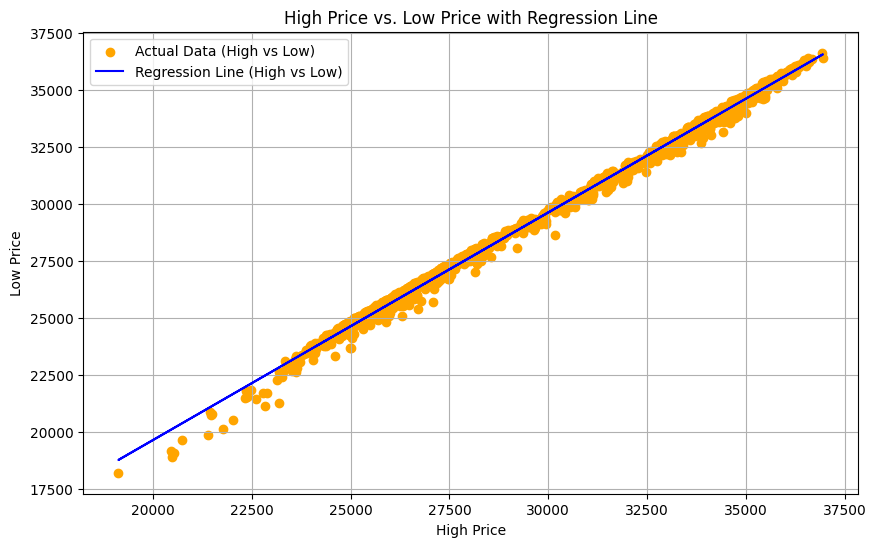

In [22]:
import matplotlib.pyplot as plt

# Predict y values using the trained model (on the full X_high for visualization)
y_pred_low = model_high_low.predict(X_high)

# Create the scatter plot of original data points
plt.figure(figsize=(10, 6))
plt.scatter(X_high, y_low, color='orange', label='Actual Data (High vs Low)')

# Overlay the regression line
plt.plot(X_high, y_pred_low, color='blue', label='Regression Line (High vs Low)')

# Add labels, title, and legend
plt.xlabel('High Price')
plt.ylabel('Low Price')
plt.title('High Price vs. Low Price with Regression Line')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set for 'High' vs 'Low'
y_pred_test_low = model_high_low.predict(X_test_high)

# Calculate evaluation metrics
mae_high_low = mean_absolute_error(y_test_low, y_pred_test_low)
mse_high_low = mean_squared_error(y_test_low, y_pred_test_low)
rmse_high_low = np.sqrt(mse_high_low)
r2_high_low = r2_score(y_test_low, y_pred_test_low)

# Print the metrics
print(f"Mean Absolute Error (MAE) for High vs Low: {mae_high_low:.2f}")
print(f"Mean Squared Error (MSE) for High vs Low: {mse_high_low:.2f}")
print(f"Root Mean Squared Error (RMSE) for High vs Low: {rmse_high_low:.2f}")
print(f"R-squared (R2) for High vs Low: {r2_high_low:.4f}")

Mean Absolute Error (MAE) for High vs Low: 183.46
Mean Squared Error (MSE) for High vs Low: 61021.17
Root Mean Squared Error (RMSE) for High vs Low: 247.02
R-squared (R2) for High vs Low: 0.9962


#MULTIPLE LINEAR REGRESSION TO PREDICT CLOSE.

Also trying to implement multiple linear regression to detect the close of a particular day.

In [24]:
from sklearn.model_selection import train_test_split

# 1. Define the independent variables (features) X_multi
X_multi = df[['Open', 'High', 'Low', 'Volume']]

# 2. Define the dependent variable (target) y_multi
y_multi = df['Close*']

# 3. Split the X_multi and y_multi data into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# 4. Print the shapes of the split data
print("Shape of X_train_multi:", X_train_multi.shape)
print("Shape of X_test_multi:", X_test_multi.shape)
print("Shape of y_train_multi:", y_train_multi.shape)
print("Shape of y_test_multi:", y_test_multi.shape)

Shape of X_train_multi: (1006, 4)
Shape of X_test_multi: (252, 4)
Shape of y_train_multi: (1006,)
Shape of y_test_multi: (252,)


In [25]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Instantiate a LinearRegression object
model_multi = LinearRegression()

# Fit the model to the training data
model_multi.fit(X_train_multi, y_train_multi)

# Print the model's intercept
print(f"Model Intercept: {model_multi.intercept_:.2f}")

# Print the model's coefficients along with their corresponding feature names
coefficients_df = pd.DataFrame({'Feature': X_train_multi.columns, 'Coefficient': model_multi.coef_})
print("\nModel Coefficients:")
print(coefficients_df)

Model Intercept: 9.14

Model Coefficients:
  Feature   Coefficient
0    Open -6.176911e-01
1    High  8.184451e-01
2     Low  7.994053e-01
3  Volume -1.608281e-08


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set for the multiple linear regression model
y_pred_multi = model_multi.predict(X_test_multi)

# Calculate evaluation metrics
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

# Print the metrics
print(f"Mean Absolute Error (MAE) for Multiple LR: {mae_multi:.2f}")
print(f"Mean Squared Error (MSE) for Multiple LR: {mse_multi:.2f}")
print(f"Root Mean Squared Error (RMSE) for Multiple LR: {rmse_multi:.2f}")
print(f"R-squared (R2) for Multiple LR: {r2_multi:.4f}")

Mean Absolute Error (MAE) for Multiple LR: 83.89
Mean Squared Error (MSE) for Multiple LR: 13354.94
Root Mean Squared Error (RMSE) for Multiple LR: 115.56
R-squared (R2) for Multiple LR: 0.9992


/tmp/ipython-input-1021649420.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Coefficient', data=coefficients_df, palette='viridis')


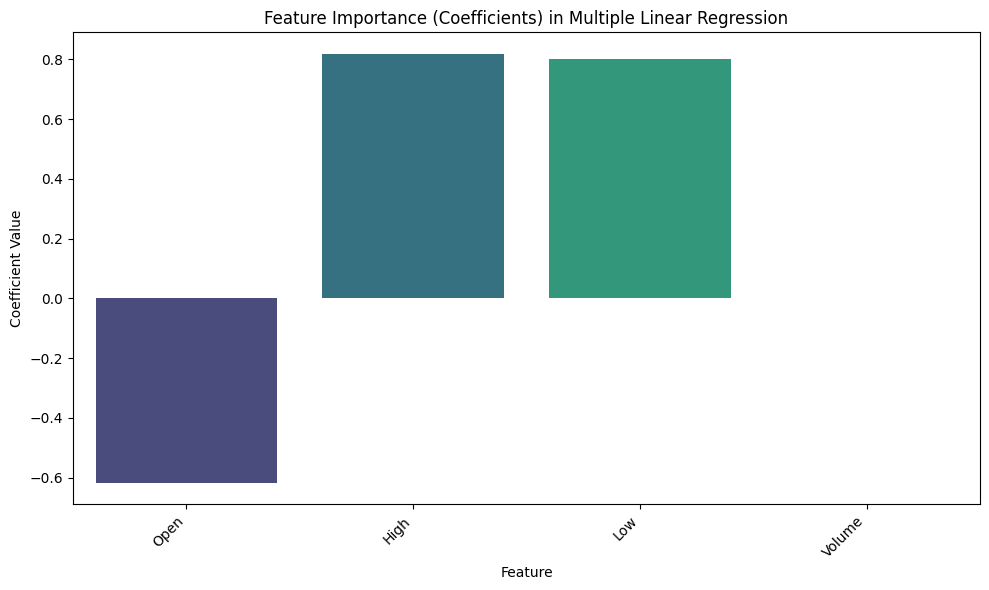

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Coefficient', data=coefficients_df, palette='viridis')

# Add labels, title, and legend
plt.title('Feature Importance (Coefficients) in Multiple Linear Regression')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
